In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Load the data from csv
data = pd.read_csv("Creditcard_data(1).csv")

# Create feature-target splits
X = data.drop("Class", axis=1)
y = data["Class"]

print("Class distribution:")
print(y.value_counts())

Class distribution:
Class
0    763
1      9
Name: count, dtype: int64


In [ ]:
# Combine features (X) and target (y) into one DataFrame
full_data = pd.concat([X, y], axis=1)

# Split data by class
majority = full_data[full_data["Class"] == 0]  # majority class
minority = full_data[full_data["Class"] == 1]  # minority class

# Upsample minority class to match majority size
minority_upsampled = minority.sample(
    n=len(majority),
    replace=True,        # allow duplicates
    random_state=42      # reproducibility
)

# Combine majority and upsampled minority data
balanced_data = pd.concat([majority, minority_upsampled])

# Shuffle the balanced dataset
balanced_data = balanced_data.sample(frac=1, random_state=42)

# Separate features and target again
X_bal = balanced_data.drop("Class", axis=1)
y_bal = balanced_data["Class"]

# Verify class balance
print("Balanced class distribution:")
print(y_bal.value_counts())

Balanced class distribution:
Class
1    763
0    763
Name: count, dtype: int64


In [ ]:
# Models to compare
models = {
    "M1_LogisticRegression": LogisticRegression(max_iter=5000),
    "M2_KNN": KNeighborsClassifier(),
    "M3_DecisionTree": DecisionTreeClassifier(random_state=100),
    "M4_RandomForest": RandomForestClassifier(random_state=100),
    "M5_SVM": SVC()
}


In [ ]:
# Simple Random Split
def sampling1():
    return train_test_split(
        X_bal, y_bal,
        test_size=0.25,
        random_state=1,
        shuffle=True
    )

In [ ]:
# Stratified Split
def sampling2():
    return train_test_split(
        X_bal, y_bal,
        test_size=0.25,
        random_state=2,
        stratify=y_bal
    )

In [ ]:
# Bootstrapping
def sampling3():
    boot = pd.concat([X_bal, y_bal], axis=1).sample(
        frac=1,
        replace=True,
        random_state=3
    )

    Xb = boot.drop("Class", axis=1)
    yb = boot["Class"]

    return train_test_split(
        Xb, yb,
        test_size=0.25,
        random_state=3
    )

In [ ]:
from sklearn.model_selection import KFold

# KFold
def sampling4():
    kf = KFold(n_splits=5, shuffle=True, random_state=4)
    train_idx, test_idx = next(kf.split(X_bal))

    return (
        X_bal.iloc[train_idx],
        X_bal.iloc[test_idx],
        y_bal.iloc[train_idx],
        y_bal.iloc[test_idx]
    )

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Stratified K-Fold
def sampling5():
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
    train_idx, test_idx = next(skf.split(X_bal, y_bal))

    return (
        X_bal.iloc[train_idx],
        X_bal.iloc[test_idx],
        y_bal.iloc[train_idx],
        y_bal.iloc[test_idx]
    )

In [ ]:
# Store samplers
samplers = [sampling1, sampling2, sampling3, sampling4, sampling5]
sampler_names = ["Sampling1", "Sampling2", "Sampling3", "Sampling4", "Sampling5"]

# Results table
results = pd.DataFrame(index=models.keys(), columns=sampler_names)

# Train & evaluate
for i, sampler in enumerate(samplers):
    X_train, X_test, y_train, y_test = sampler()

    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train each model
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results.loc[model_name, sampler_names[i]] = round(acc * 100, 2)

In [ ]:
results

,Sampling1,Sampling2,Sampling3,Sampling4,Sampling5
M1_LogisticRegression,92.15,92.15,90.05,92.48,92.16
M2_KNN,98.69,97.64,98.17,96.73,98.04
M3_DecisionTree,99.74,98.17,99.74,99.02,99.35
M4_RandomForest,100.0,100.0,100.0,100.0,100.0
M5_SVM,98.69,98.17,98.69,97.39,97.39


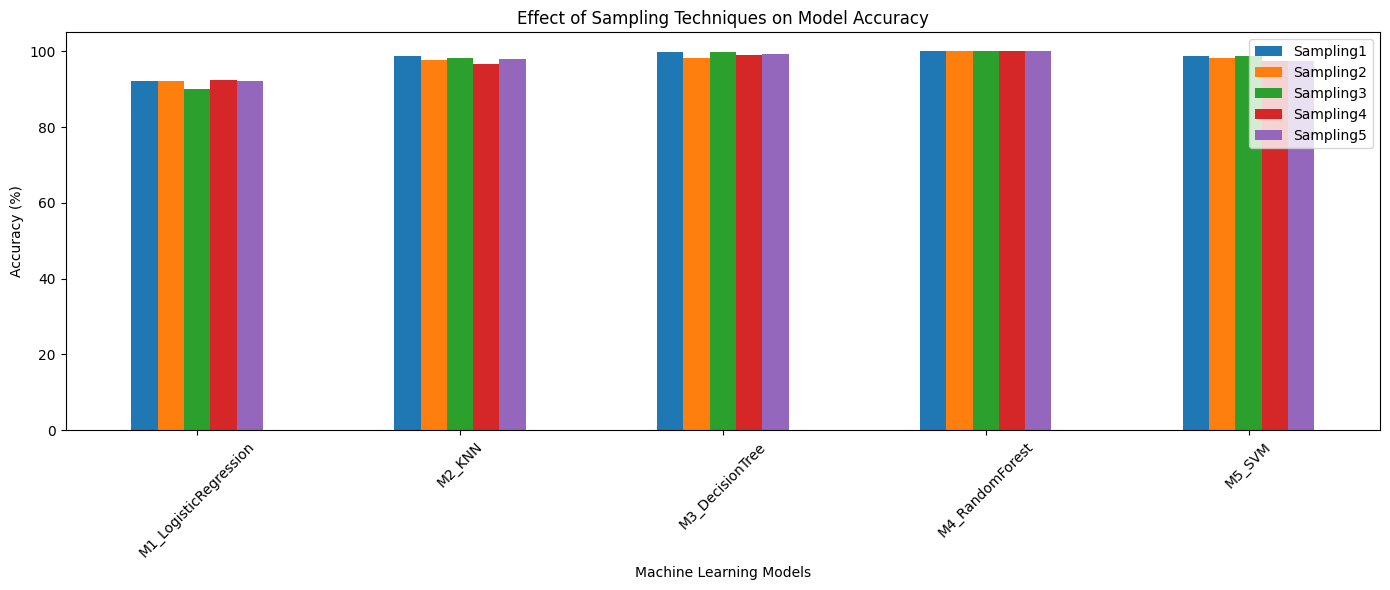

In [ ]:
# Convert results to float and plot accuracy comparison
results.astype(float).plot(
    kind="bar",
    figsize=(14, 6)
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Models")
plt.title("Effect of Sampling Techniques on Model Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Identify best sampling technique for each model
best_sampling = results.astype(float).idxmax(axis=1)

# Store results in a clean DataFrame
best_sampling_df = pd.DataFrame({
    "Best Sampling Technique": best_sampling
})

best_sampling_df

,Best Sampling Technique
M1_LogisticRegression,Sampling4
M2_KNN,Sampling1
M3_DecisionTree,Sampling1
M4_RandomForest,Sampling1
M5_SVM,Sampling1


**Conclusion:**

The credit card dataset was originally highly imbalanced, which could cause
machine learning models to favor the majority class. To address this, the data
was first balanced so both classes were treated equally during training.

Five sampling techniques were then applied and evaluated across five machine
learning models. The results show that Simple Random Sampling performed best for
most models once the data was balanced, as it preserved the natural structure of
the dataset without introducing unnecessary noise.

Logistic Regression behaved differently, achieving its best performance with a
more structured sampling method due to its linear nature. Overall, the results
highlight that sampling strategy should be chosen based on both the dataset and
the model being used.